# EDA + Feature Importance — Aggravated Assault
## ICPSR 34562: Recidivism in the NLSY97

Este dataset contiene información longitudinal sobre **8,984 jóvenes** nacidos entre 1980-1984 en EE.UU., seguidos desde los 14 hasta los 25 años (1994–2009).

### Estructura del dataset
Las variables siguen un patrón `NOMBRE_CY{edad}` donde el sufijo indica la edad del respondente cuando se midió esa variable:
- `CY14` = año en que el respondente tenía 14 años
- `CY23` = año en que tenía 23 años

### Dos datasets
- **DS0001** (n=8,984): Crímenes auto-reportados, rondas 1-7 (edades 14-23)
- **DS0002** (n=2,977): Extensión, rondas 8-13 (edades 24-25), submuestra encarcelados

### Variable objetivo
**`ASSAULT_CY{edad}`** = número de asaltos auto-reportados ese año de edad. Construiremos `EVER_ASSAULT`: indicador binario de si la persona reportó ≥1 asalto en cualquier momento.

## 0. Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

BASE = Path('data/ICPSR_34562')
DS1_PATH = BASE / 'DS0001/34562-0001-Data.dta'
DS2_PATH = BASE / 'DS0002/34562-0002-Data.dta'

## 1. Carga y limpieza de datos

### Códigos especiales de missing en NLSY97
Los valores negativos NO son datos reales — son códigos que indican por qué falta el valor:

| Código | Significado |
|--------|-------------|
| -3 a -9 | Varios tipos de missing (skip inválido, skip válido, no entrevistado, etc.) |

Todos se reemplazan por `NaN`.

In [5]:
# Cargar DS0001 (todos los respondentes, edades 14-23)
ds1_raw = pd.read_stata(DS1_PATH, convert_categoricals=False)
print(f"DS0001 cargado: {ds1_raw.shape[0]:,} individuos × {ds1_raw.shape[1]} variables")

# Cargar DS0002 (submuestra con datos de edades 24-25)
ds2_raw = pd.read_stata(DS2_PATH, convert_categoricals=False)
print(f"DS0002 cargado: {ds2_raw.shape[0]:,} individuos × {ds2_raw.shape[1]} variables")

DS0001 cargado: 8,984 individuos × 392 variables
DS0002 cargado: 2,977 individuos × 405 variables


In [6]:
def clean_nlsy(df: pd.DataFrame) -> pd.DataFrame:
    """Reemplaza todos los códigos negativos de missing por NaN."""
    df = df.copy()
    num_cols = df.select_dtypes(include='number').columns
    df[num_cols] = df[num_cols].where(df[num_cols] >= 0, np.nan)
    return df

ds1 = clean_nlsy(ds1_raw)
ds2 = clean_nlsy(ds2_raw)

# Merge con DS0002 para agregar ASSAULT_CY24 y ASSAULT_CY25
assault24_25 = ds2[['PUBID', 'ASSAULT_CY24', 'ASSAULT_CY25']]
df = ds1.merge(assault24_25, on='PUBID', how='left')

print(f"Dataset final: {df.shape[0]:,} individuos × {df.shape[1]} variables")

Dataset final: 8,984 individuos × 394 variables


## 2. Catálogo completo de variables

Aquí está el mapa completo de qué mide cada familia de variables:

| Grupo | Variables | Descripción |
|-------|-----------|-------------|
| **Crimen auto-reportado** | `ASSAULT_CY{14-25}` | Nº de asaltos ese año de edad |
| | `DESTROY_CY{14-23}` | Destrucción de propiedad ajena |
| | `STEAL_UNDER_50_CY{14-23}` | Robo < $50 |
| | `STEAL_OVER_50_CY{14-23}` | Robo > $50 |
| | `OTHER_PROPERTY_CY{14-23}` | Otros delitos contra la propiedad |
| | `SELL_DRUGS_CY{14-23}` | Venta de drogas |
| **Sistema de justicia** | `EVER_ARR_CY{14-25}` | Alguna vez arrestado a esa edad |
| | `MOS_INCARC_CY{14-25}` | Meses encarcelado ese año |
| | `EVER_INCARC_CY{14-25}` | Alguna vez encarcelado a esa edad |
| | `EVER_CONV_CY{14-25}` | Alguna vez condenado a esa edad |
| | `FIRSTARREST` | Edad del primer arresto |
| | `TOTARRESTS` | Total de arrestos (toda la vida) |
| | `FIRSTINCARC` / `TOTINCARC` | Primer encarcelamiento / total |
| **Sustancias** | `ALCOHOL_CY{14-25}` | Consumo de alcohol ese año |
| | `MARIJUANA_CY{14-25}` | Consumo de marihuana |
| | `HARD_DRUGS_CY{14-25}` | Drogas duras |
| | `SMOKING_CY{14-25}` | Tabaquismo |
| **Comportamiento** | `CARR_GUN_CY{14-25}` | Portó arma de fuego |
| | `IN_A_GANG_CY{14-25}` | Miembro de pandilla |
| | `GANGS_CY{14-25}` | Actividad de pandillas |
| | `RUNAWAY_CY{14-18}` | Fugitivo de casa |
| **Trabajo** | `WKS_WK_CY{14-25}` | Semanas trabajadas |
| | `AVG_HRS_WK_CY{14-25}` | Horas promedio por semana |
| | `RINC_CY{14-25}` | Ingreso del respondente |
| | `HHINC_CY{14-25}` | Ingreso del hogar |
| **Educación** | `ENROLL_ED_CY{14-25}` | Inscrito en educación |
| | `HGC_CY{14-25}` | Grado más alto completado |
| | `HDR_CY{14-25}` | Tiene diploma de bachillerato |
| **Familia** | `MARSTAT_CY{14-25}` | Estado civil |
| | `BKIDS_TTL_CY{14-25}` | Hijos biológicos totales |
| **Perfil estático (1997)** | `SEX` | 1=Hombre, 2=Mujer |
| | `RACE_ETHNICITY` | 1=Negro, 2=Hispano, 3=Mixto, 4=Otro |
| | `BIOMOMAGE` | Edad de la madre biológica |
| | `NUMSIBS` | Número de hermanos |
| | `MOMEMP97` | Empleo de la madre en 1997 |
| | `DADEMP97` | Empleo del padre en 1997 |
| | `FMSTRC97` | Estructura familiar en 1997 |
| | `RESPARED` | Educación de los padres |
| | `POVRATIO97` | Ratio de pobreza familiar (1997) |
| | `ASVAB_SCORE` | Puntaje de aptitud cognitiva (ASVAB) |
| | `HEALTHLIMIT2002` | Limitación de salud en 2002 |

In [7]:
# Definir grupos de columnas para uso posterior
AGES = list(range(14, 26))

assault_cols   = [f'ASSAULT_CY{a}' for a in AGES if f'ASSAULT_CY{a}' in df.columns]
destroy_cols   = [f'DESTROY_CY{a}' for a in AGES if f'DESTROY_CY{a}' in df.columns]
steal_lo_cols  = [f'STEAL_UNDER_50_CY{a}' for a in AGES if f'STEAL_UNDER_50_CY{a}' in df.columns]
steal_hi_cols  = [f'STEAL_OVER_50_CY{a}' for a in AGES if f'STEAL_OVER_50_CY{a}' in df.columns]
drugs_sell_cols= [f'SELL_DRUGS_CY{a}' for a in AGES if f'SELL_DRUGS_CY{a}' in df.columns]
arr_cols       = [f'EVER_ARR_CY{a}' for a in AGES if f'EVER_ARR_CY{a}' in df.columns]
incarc_cols    = [f'MOS_INCARC_CY{a}' for a in AGES if f'MOS_INCARC_CY{a}' in df.columns]
alcohol_cols   = [f'ALCOHOL_CY{a}' for a in AGES if f'ALCOHOL_CY{a}' in df.columns]
marijuana_cols = [f'MARIJUANA_CY{a}' for a in AGES if f'MARIJUANA_CY{a}' in df.columns]
hard_cols      = [f'HARD_DRUGS_CY{a}' for a in AGES if f'HARD_DRUGS_CY{a}' in df.columns]
smoking_cols   = [f'SMOKING_CY{a}' for a in AGES if f'SMOKING_CY{a}' in df.columns]
gun_cols       = [f'CARR_GUN_CY{a}' for a in AGES if f'CARR_GUN_CY{a}' in df.columns]
gang_cols      = [f'IN_A_GANG_CY{a}' for a in AGES if f'IN_A_GANG_CY{a}' in df.columns]
hhinc_cols     = [f'HHINC_CY{a}' for a in AGES if f'HHINC_CY{a}' in df.columns]
rinc_cols      = [f'RINC_CY{a}' for a in AGES if f'RINC_CY{a}' in df.columns]
wks_cols       = [f'WKS_WK_CY{a}' for a in AGES if f'WKS_WK_CY{a}' in df.columns]
hgc_cols       = [f'HGC_CY{a}' for a in AGES if f'HGC_CY{a}' in df.columns]

STATIC_COLS = ['SEX', 'RACE_ETHNICITY', 'BIOMOMAGE', 'NUMSIBS', 'MOMEMP97',
               'DADEMP97', 'FMSTRC97', 'RESPARED', 'POVRATIO97', 'ASVAB_SCORE',
               'HEALTHLIMIT2002', 'HEALTHCONDITIONS16']
STATIC_COLS = [c for c in STATIC_COLS if c in df.columns]

print(f"Variables ASSAULT encontradas: {assault_cols}")
print(f"Variables estáticas: {STATIC_COLS}")

Variables ASSAULT encontradas: ['ASSAULT_CY14', 'ASSAULT_CY15', 'ASSAULT_CY16', 'ASSAULT_CY17', 'ASSAULT_CY18', 'ASSAULT_CY19', 'ASSAULT_CY20', 'ASSAULT_CY21', 'ASSAULT_CY22', 'ASSAULT_CY23', 'ASSAULT_CY24', 'ASSAULT_CY25']
Variables estáticas: ['SEX', 'RACE_ETHNICITY', 'BIOMOMAGE', 'NUMSIBS', 'MOMEMP97', 'DADEMP97', 'FMSTRC97', 'RESPARED', 'POVRATIO97', 'ASVAB_SCORE', 'HEALTHLIMIT2002', 'HEALTHCONDITIONS16']


## 3. Construcción de la variable objetivo: EVER_ASSAULT

`EVER_ASSAULT = 1` si el individuo reportó ≥1 asalto en **cualquier** año de edad observado.

Esta variable captura a quienes alguna vez cometieron un asalto según su propio reporte.

In [8]:
# Suma total de asaltos por individuo (ignorando NaN)
df['TOTAL_ASSAULTS'] = df[assault_cols].sum(axis=1, min_count=1)
df['EVER_ASSAULT']   = (df['TOTAL_ASSAULTS'] > 0).astype(int)

# Solo consideramos individuos con al menos una observación de assault no-missing
n_observed = df[assault_cols].notna().any(axis=1).sum()
n_assault  = df['EVER_ASSAULT'].sum()
rate       = n_assault / n_observed

print(f"Individuos con al menos una observación: {n_observed:,}")
print(f"Individuos que reportaron ≥1 asalto:     {n_assault:,}")
print(f"Tasa de prevalencia de asalto:           {rate:.1%}")

Individuos con al menos una observación: 8,958
Individuos que reportaron ≥1 asalto:     2,818
Tasa de prevalencia de asalto:           31.5%


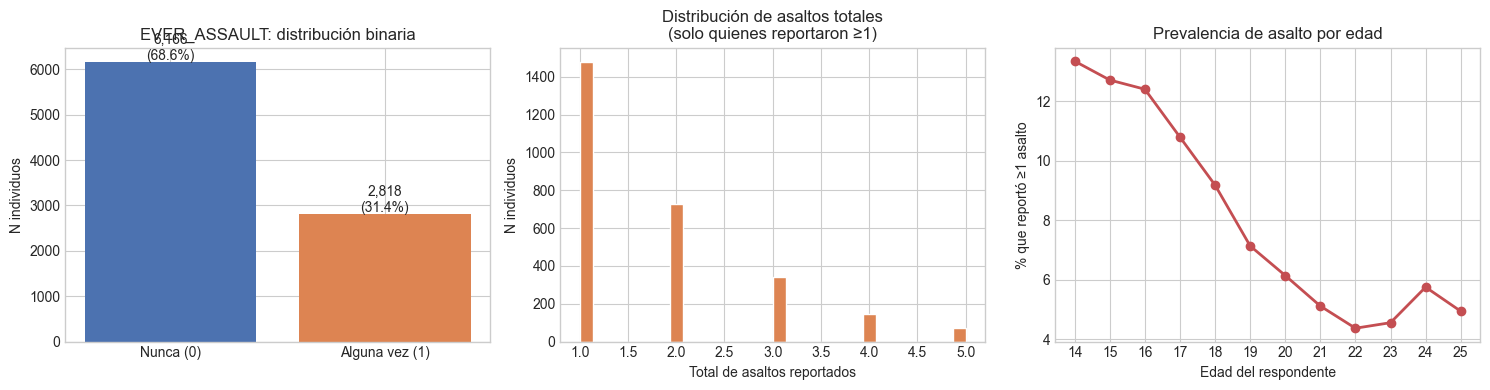

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribución binaria
vc = df['EVER_ASSAULT'].value_counts()
axes[0].bar(['Nunca (0)', 'Alguna vez (1)'], vc.values, color=['#4c72b0', '#dd8452'])
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 30, f'{v:,}\n({v/vc.sum():.1%})', ha='center', fontsize=10)
axes[0].set_title('EVER_ASSAULT: distribución binaria')
axes[0].set_ylabel('N individuos')

# Distribución de conteo total
tot = df['TOTAL_ASSAULTS'].dropna()
tot_clip = tot[tot <= tot.quantile(0.99)]
axes[1].hist(tot_clip[tot_clip > 0], bins=30, color='#dd8452', edgecolor='white')
axes[1].set_title('Distribución de asaltos totales\n(solo quienes reportaron ≥1)')
axes[1].set_xlabel('Total de asaltos reportados')
axes[1].set_ylabel('N individuos')

# Prevalencia por edad
prev_by_age = []
for col in assault_cols:
    age = int(col.replace('ASSAULT_CY', ''))
    obs = df[col].dropna()
    prev_by_age.append({'age': age, 'prevalence': (obs > 0).mean() * 100})
prev_df = pd.DataFrame(prev_by_age)
axes[2].plot(prev_df['age'], prev_df['prevalence'], marker='o', color='#c44e52', linewidth=2)
axes[2].set_title('Prevalencia de asalto por edad')
axes[2].set_xlabel('Edad del respondente')
axes[2].set_ylabel('% que reportó ≥1 asalto')
axes[2].set_xticks(prev_df['age'])

plt.tight_layout()
plt.show()

## 4. Análisis de valores faltantes

El NLSY97 tiene missing values estructurales: si un individuo no fue entrevistado en una ronda, todas sus variables de esa ronda quedan en NaN. Esto es esperable y no indica un problema en los datos.

In [10]:
# Missing por variable
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)

print("Resumen de valores faltantes:")
print(f"  Variables sin missing:       {(missing_pct == 0).sum()}")
print(f"  Variables con 1-25% missing: {((missing_pct > 0) & (missing_pct < 25)).sum()}")
print(f"  Variables con 25-75% missing:{((missing_pct >= 25) & (missing_pct < 75)).sum()}")
print(f"  Variables con >75% missing:  {(missing_pct >= 75).sum()}")
print()

# Mostrar missing de variables clave
key_vars = STATIC_COLS + assault_cols[:5]
print("Missing en variables clave:")
for v in key_vars:
    if v in df.columns:
        print(f"  {v:35s}: {missing_pct[v]:.1f}%")

Resumen de valores faltantes:
  Variables sin missing:       35
  Variables con 1-25% missing: 224
  Variables con 25-75% missing:95
  Variables con >75% missing:  42

Missing en variables clave:
  SEX                                : 0.0%
  RACE_ETHNICITY                     : 0.0%
  BIOMOMAGE                          : 6.8%
  NUMSIBS                            : 0.0%
  MOMEMP97                           : 11.9%
  DADEMP97                           : 36.8%
  FMSTRC97                           : 0.3%
  RESPARED                           : 7.0%
  POVRATIO97                         : 27.0%
  ASVAB_SCORE                        : 21.0%
  HEALTHLIMIT2002                    : 78.7%
  HEALTHCONDITIONS16                 : 0.0%
  ASSAULT_CY14                       : 61.2%
  ASSAULT_CY15                       : 42.3%
  ASSAULT_CY16                       : 23.0%
  ASSAULT_CY17                       : 6.5%
  ASSAULT_CY18                       : 9.6%


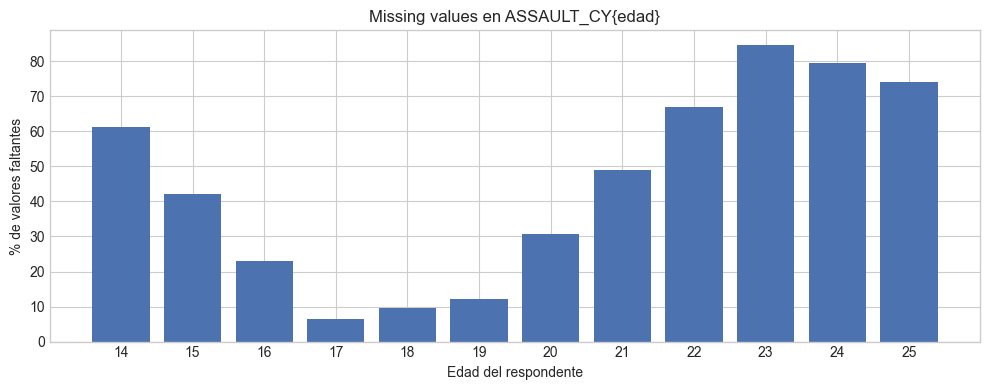


Nota: el alto % de missing en edades tempranas se debe a skip patterns
(no se preguntó a todos, o la ronda de encuesta no la cubría).
El missing en CY24-25 es por ser solo submuestra (DS0002).


In [11]:
# Missing en variables de assault por edad
assault_missing = [(col, missing_pct[col]) for col in assault_cols]
ages_a = [int(c.replace('ASSAULT_CY', '')) for c in assault_cols]
pcts_a = [missing_pct[c] for c in assault_cols]

plt.figure(figsize=(10, 4))
plt.bar(ages_a, pcts_a, color='#4c72b0')
plt.xlabel('Edad del respondente')
plt.ylabel('% de valores faltantes')
plt.title('Missing values en ASSAULT_CY{edad}')
plt.xticks(ages_a)
plt.tight_layout()
plt.show()

print("\nNota: el alto % de missing en edades tempranas se debe a skip patterns")
print("(no se preguntó a todos, o la ronda de encuesta no la cubría).")
print("El missing en CY24-25 es por ser solo submuestra (DS0002).")

## 5. Variables demográficas y de perfil estático

Estas variables se midieron en 1997 (ronda 1) y no cambian. Son el **punto de partida socioeconómico** de cada individuo.

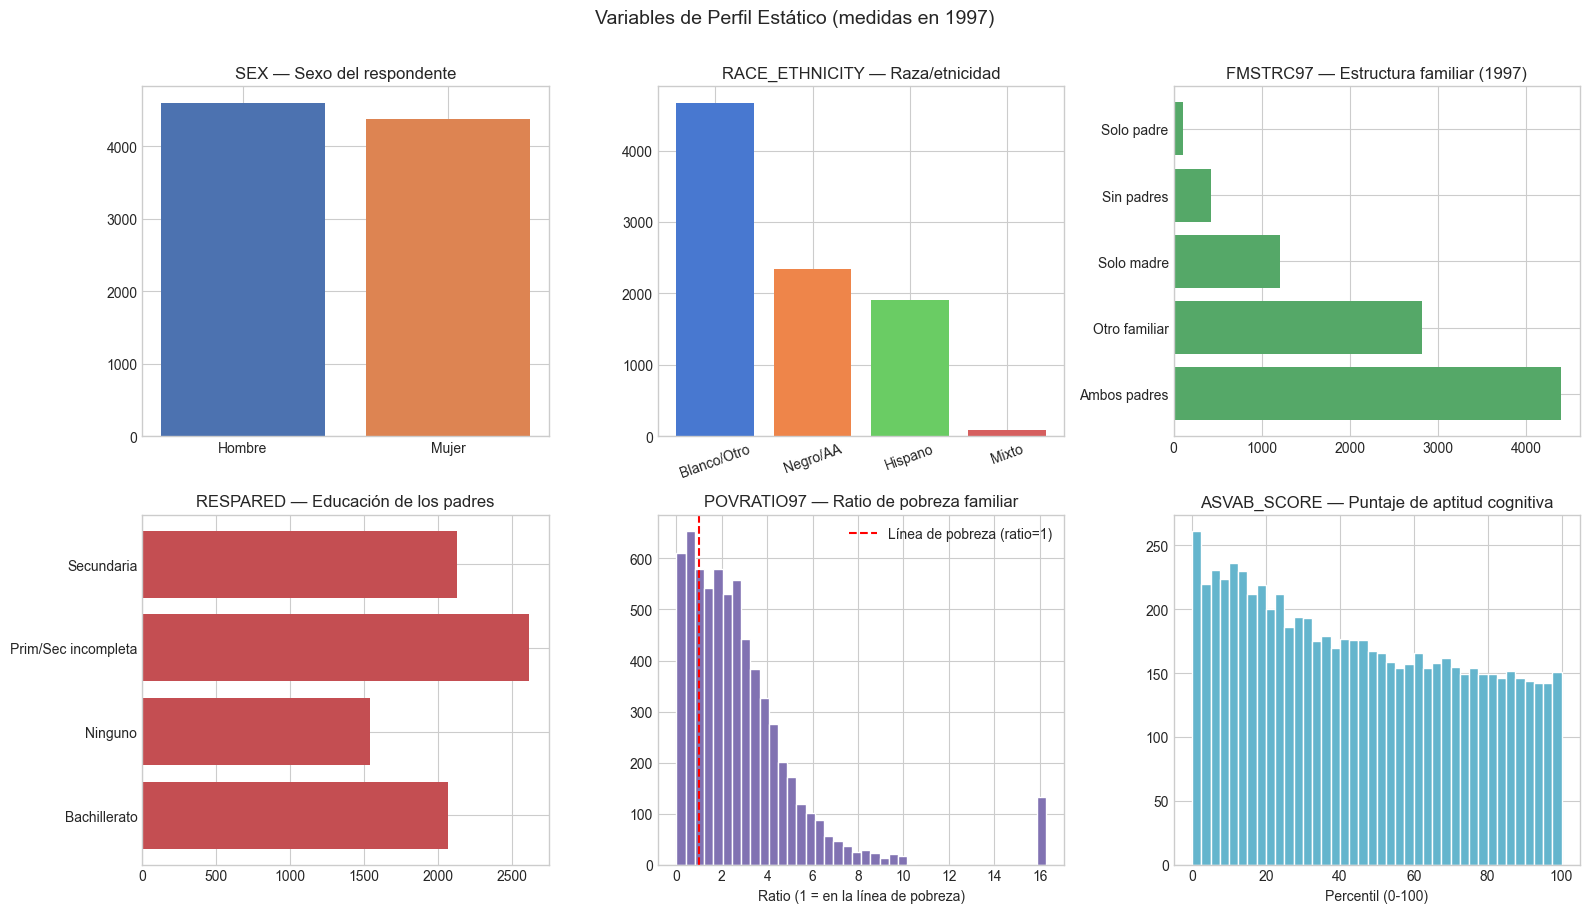

In [12]:
# Etiquetas de codificación
sex_labels        = {1: 'Hombre', 2: 'Mujer'}
race_labels       = {1: 'Negro/AA', 2: 'Hispano', 3: 'Mixto', 4: 'Blanco/Otro'}
momemp_labels     = {1: 'Con empleo', 0: 'Sin empleo'}
fmstrc_labels     = {1: 'Ambos padres', 2: 'Solo madre', 3: 'Solo padre',
                     4: 'Otro familiar', 5: 'Sin padres'}
respared_labels   = {1: 'Ninguno', 2: 'Prim/Sec incompleta', 3: 'Secundaria',
                     4: 'Bachillerato', 5: 'Algo de uni', 6: 'Licenciatura',
                     7: 'Posgrado'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# SEX
vc = df['SEX'].map(sex_labels).value_counts()
axes[0].bar(vc.index, vc.values, color=['#4c72b0', '#dd8452'])
axes[0].set_title('SEX — Sexo del respondente')

# RACE_ETHNICITY
vc = df['RACE_ETHNICITY'].map(race_labels).value_counts()
axes[1].bar(vc.index, vc.values, color=sns.color_palette('muted', 4))
axes[1].set_title('RACE_ETHNICITY — Raza/etnicidad')
axes[1].tick_params(axis='x', rotation=20)

# FMSTRC97 — Estructura familiar
vc = df['FMSTRC97'].map(fmstrc_labels).value_counts()
axes[2].barh(vc.index, vc.values, color='#55a868')
axes[2].set_title('FMSTRC97 — Estructura familiar (1997)')

# RESPARED — Educación de padres
vc = df['RESPARED'].map(respared_labels).value_counts().sort_index()
axes[3].barh(list(vc.index), vc.values, color='#c44e52')
axes[3].set_title('RESPARED — Educación de los padres')

# POVRATIO97 — Ratio de pobreza
pov = df['POVRATIO97'].dropna()
axes[4].hist(pov, bins=40, color='#8172b2', edgecolor='white')
axes[4].axvline(1.0, color='red', linestyle='--', label='Línea de pobreza (ratio=1)')
axes[4].set_title('POVRATIO97 — Ratio de pobreza familiar')
axes[4].set_xlabel('Ratio (1 = en la línea de pobreza)')
axes[4].legend()

# ASVAB_SCORE — Aptitud cognitiva
asv = df['ASVAB_SCORE'].dropna()
axes[5].hist(asv, bins=40, color='#64b5cd', edgecolor='white')
axes[5].set_title('ASVAB_SCORE — Puntaje de aptitud cognitiva')
axes[5].set_xlabel('Percentil (0-100)')

plt.suptitle('Variables de Perfil Estático (medidas en 1997)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# Estadísticas descriptivas de variables estáticas
print("Estadísticas descriptivas — variables de perfil (1997):")
desc = df[STATIC_COLS].describe().T
desc['missing_%'] = df[STATIC_COLS].isna().mean() * 100
desc[['count', 'mean', 'std', 'min', 'max', 'missing_%']].round(2)

Estadísticas descriptivas — variables de perfil (1997):


,count,mean,std,min,max,missing_%
SEX,8984.00,1.49,0.50,1.00,2.00,0.00
RACE_ETHNICITY,8984.00,2.79,1.31,1.00,4.00,0.00
BIOMOMAGE,8372.00,25.49,5.41,12.00,54.00,6.81
NUMSIBS,8984.00,1.55,1.28,0.00,13.00,0.00
MOMEMP97,7915.00,0.77,0.50,0.00,2.00,11.90
DADEMP97,5681.00,0.90,0.31,0.00,2.00,36.77
FMSTRC97,8953.00,2.29,1.45,1.00,5.00,0.35
RESPARED,8351.00,2.57,1.05,1.00,4.00,7.05
POVRATIO97,6559.00,2.83,2.70,0.00,16.27,26.99
ASVAB_SCORE,7093.00,45.32,29.17,0.00,100.00,21.05


## 6. Crimen auto-reportado a lo largo del tiempo

El dataset incluye 6 tipos de crímenes auto-reportados, medidos cada año de edad. Esto nos permite ver **trayectorias criminales** a lo largo del tiempo.

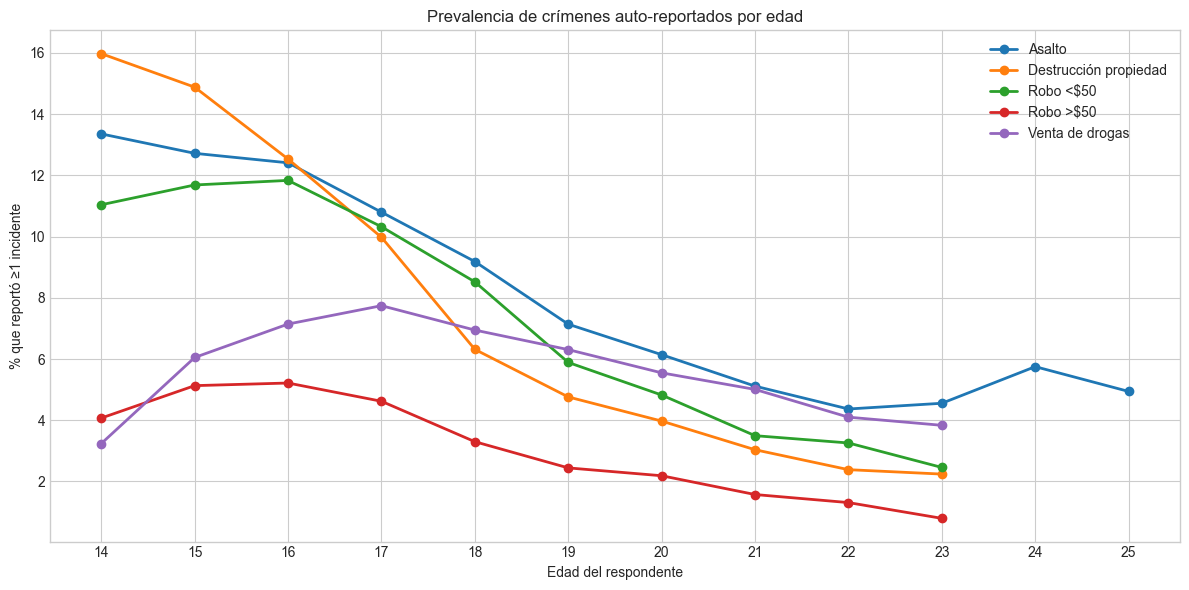

In [14]:
# Prevalencia de cada tipo de crimen por edad
crime_groups = {
    'Asalto':              assault_cols,
    'Destrucción propiedad': destroy_cols,
    'Robo <$50':           steal_lo_cols,
    'Robo >$50':           steal_hi_cols,
    'Venta de drogas':     drugs_sell_cols,
}

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('tab10', len(crime_groups))

for (name, cols), color in zip(crime_groups.items(), colors):
    ages = [int(c.split('CY')[1]) for c in cols]
    prevs = [(df[c].dropna() > 0).mean() * 100 for c in cols]
    ax.plot(ages, prevs, marker='o', label=name, color=color, linewidth=2)

ax.set_xlabel('Edad del respondente')
ax.set_ylabel('% que reportó ≥1 incidente')
ax.set_title('Prevalencia de crímenes auto-reportados por edad')
ax.legend(loc='upper right')
ax.set_xticks(range(14, 26))
plt.tight_layout()
plt.show()

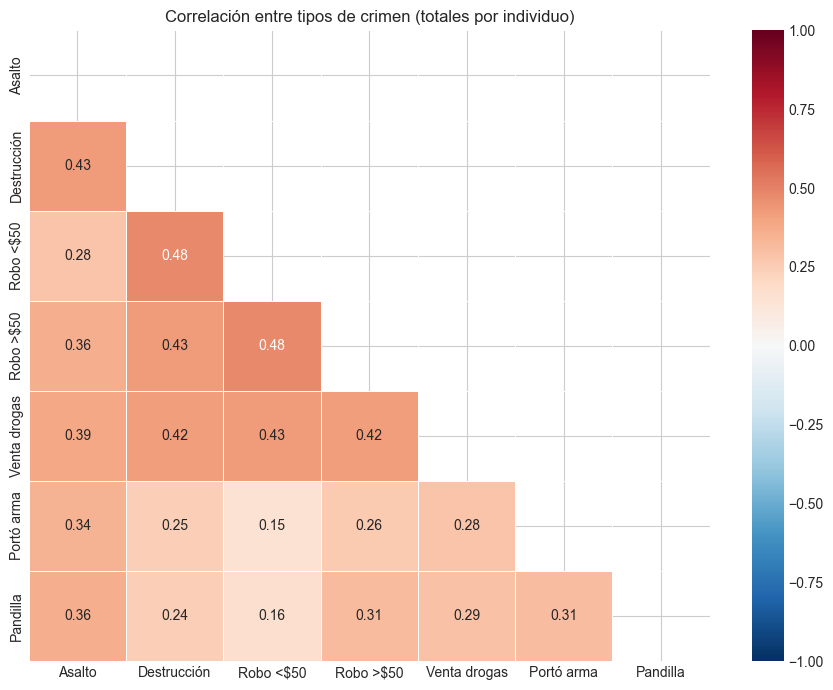

In [15]:
# Correlación entre tipos de crimen (usando totales por individuo)
crime_totals = pd.DataFrame({
    'Asalto':               df[assault_cols].sum(axis=1, min_count=1),
    'Destrucción':          df[destroy_cols].sum(axis=1, min_count=1),
    'Robo <$50':            df[steal_lo_cols].sum(axis=1, min_count=1),
    'Robo >$50':            df[steal_hi_cols].sum(axis=1, min_count=1),
    'Venta drogas':         df[drugs_sell_cols].sum(axis=1, min_count=1),
    'Portó arma':           df[gun_cols].sum(axis=1, min_count=1),
    'Pandilla':             df[gang_cols].sum(axis=1, min_count=1),
})

fig, ax = plt.subplots(figsize=(9, 7))
corr = crime_totals.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlación entre tipos de crimen (totales por individuo)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Sistema de justicia criminal

Estas variables registran **contacto oficial** con el sistema: arrestos, encarcelamientos y condenas. A diferencia del auto-reporte, capturan solo los crímenes detectados por las autoridades.

In [16]:
# Variables resumen del sistema de justicia
justice_summary = ['FIRSTARREST', 'TOTARRESTS', 'FIRSTINCARC', 'TOTINCARC', 'AGE_FIRSTINCARC']
justice_summary = [c for c in justice_summary if c in df.columns]

print("Variables de justicia criminal — estadísticas:")
desc = df[justice_summary].describe().T
desc['missing_%'] = df[justice_summary].isna().mean() * 100
print(desc[['count', 'mean', 'std', 'min', '50%', 'max', 'missing_%']].round(2))

Variables de justicia criminal — estadísticas:
                  count      mean    std       min       50%       max  \
FIRSTARREST     2926.00 200001.35 398.65 198703.00 200001.00 200912.00   
TOTARRESTS      8984.00      1.14   3.17      0.00      0.00     63.00   
FIRSTINCARC      657.00 200318.80 329.42 199306.00 200305.00 200912.00   
TOTINCARC       8984.00      0.13   0.55      0.00      0.00      7.00   
AGE_FIRSTINCARC  657.00     20.82   3.18     11.00     21.00     28.00   

                 missing_%  
FIRSTARREST          67.43  
TOTARRESTS            0.00  
FIRSTINCARC          92.69  
TOTINCARC             0.00  
AGE_FIRSTINCARC      92.69  


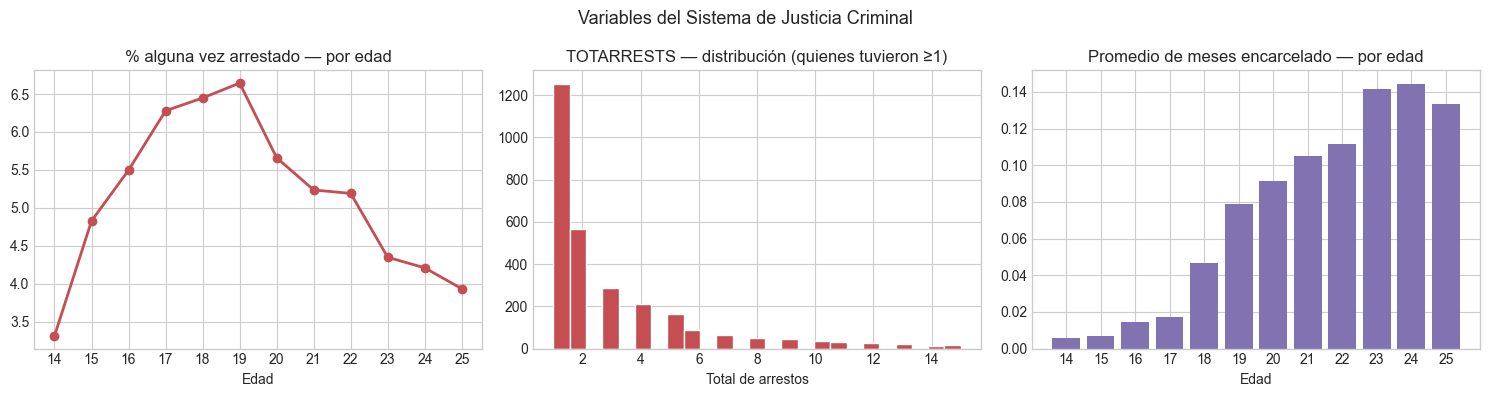

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Prevalencia de arresto por edad
arr_prev = [(df[c].dropna() > 0).mean() * 100 for c in arr_cols]
arr_ages = [int(c.replace('EVER_ARR_CY', '')) for c in arr_cols]
axes[0].plot(arr_ages, arr_prev, marker='o', color='#c44e52', linewidth=2)
axes[0].set_title('% alguna vez arrestado — por edad')
axes[0].set_xlabel('Edad'); axes[0].set_xticks(arr_ages)

# TOTARRESTS — distribución
ta = df['TOTARRESTS'].dropna()
ta = ta[ta <= ta.quantile(0.99)]
axes[1].hist(ta[ta > 0], bins=25, color='#c44e52', edgecolor='white')
axes[1].set_title('TOTARRESTS — distribución (quienes tuvieron ≥1)')
axes[1].set_xlabel('Total de arrestos')

# Meses encarcelado promedio por edad
mos_avg = [df[c].clip(lower=0).mean() for c in incarc_cols]
mos_ages= [int(c.replace('MOS_INCARC_CY', '')) for c in incarc_cols]
axes[2].bar(mos_ages, mos_avg, color='#8172b2')
axes[2].set_title('Promedio de meses encarcelado — por edad')
axes[2].set_xlabel('Edad'); axes[2].set_xticks(mos_ages)

plt.suptitle('Variables del Sistema de Justicia Criminal', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Uso de sustancias

Alcohol, marihuana y drogas duras son predictores ampliamente estudiados de comportamiento violento. El NLSY97 los mide en cada ronda.

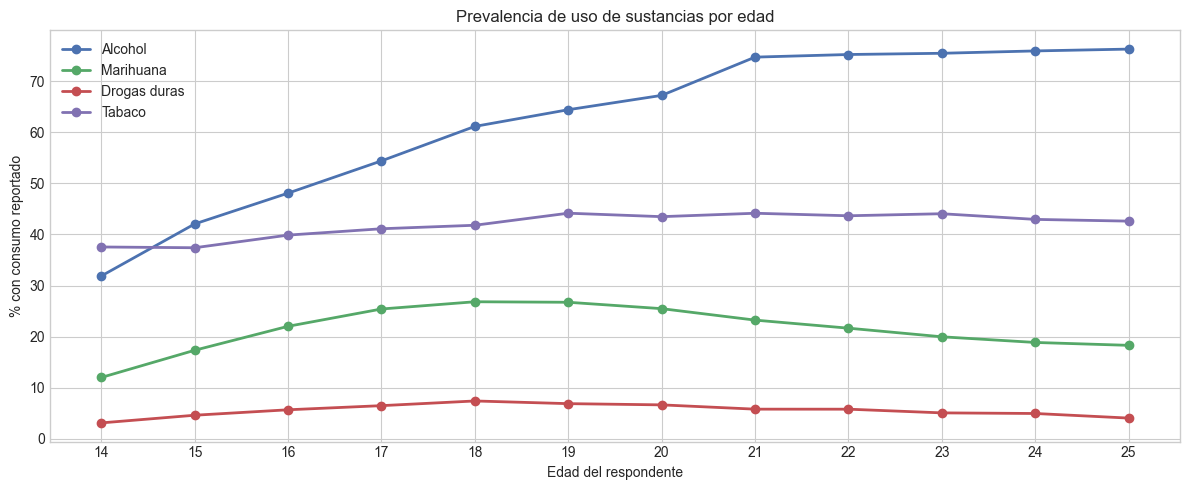

In [18]:
substance_groups = {
    'Alcohol':      alcohol_cols,
    'Marihuana':    marijuana_cols,
    'Drogas duras': hard_cols,
    'Tabaco':       smoking_cols,
}

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']
for (name, cols), color in zip(substance_groups.items(), colors):
    if not cols:
        continue
    ages = [int(c.split('CY')[1]) for c in cols]
    prevs = [(df[c].dropna() > 0).mean() * 100 for c in cols]
    ax.plot(ages, prevs, marker='o', label=name, color=color, linewidth=2)

ax.set_xlabel('Edad del respondente')
ax.set_ylabel('% con consumo reportado')
ax.set_title('Prevalencia de uso de sustancias por edad')
ax.legend()
ax.set_xticks(range(14, 26))
plt.tight_layout()
plt.show()

## 9. Variables económicas

`RINC_CY{edad}` = ingreso propio del respondente ese año.  
`HHINC_CY{edad}` = ingreso total del hogar.  
`POVRATIO97` = ingreso familiar / línea de pobreza en 1997.

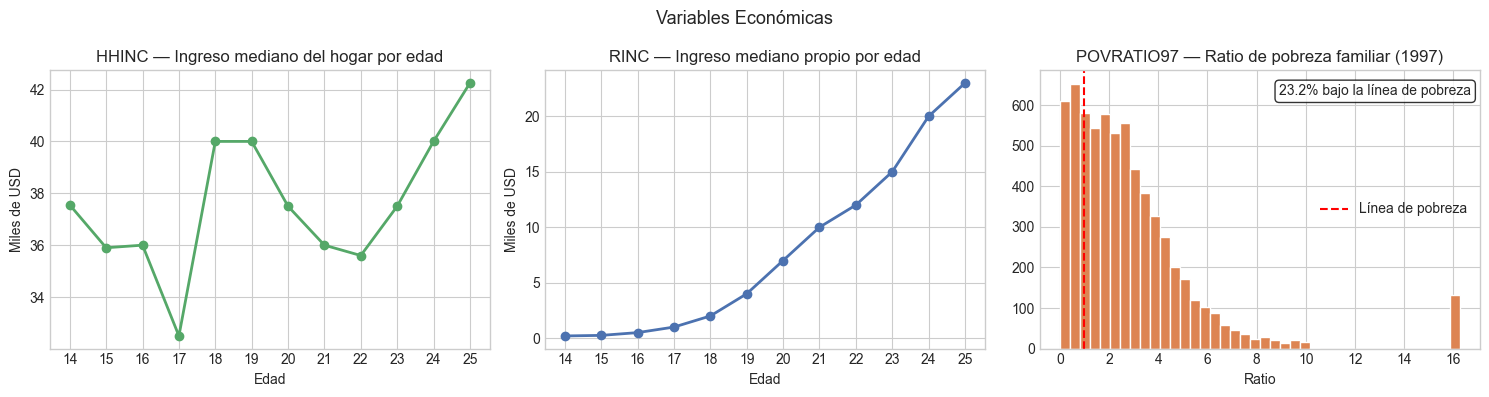

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Ingreso del hogar promedio por edad
hhinc_avg = [df[c].clip(lower=0).median() for c in hhinc_cols]
hhinc_ages= [int(c.replace('HHINC_CY', '')) for c in hhinc_cols]
axes[0].plot(hhinc_ages, [x/1000 for x in hhinc_avg], marker='o', color='#55a868', linewidth=2)
axes[0].set_title('HHINC — Ingreso mediano del hogar por edad')
axes[0].set_xlabel('Edad'); axes[0].set_ylabel('Miles de USD')
axes[0].set_xticks(hhinc_ages)

# Ingreso propio promedio por edad
rinc_avg = [df[c].clip(lower=0).median() for c in rinc_cols]
rinc_ages= [int(c.replace('RINC_CY', '')) for c in rinc_cols]
axes[1].plot(rinc_ages, [x/1000 for x in rinc_avg], marker='o', color='#4c72b0', linewidth=2)
axes[1].set_title('RINC — Ingreso mediano propio por edad')
axes[1].set_xlabel('Edad'); axes[1].set_ylabel('Miles de USD')
axes[1].set_xticks(rinc_ages)

# Ratio de pobreza al inicio (1997)
pov = df['POVRATIO97'].dropna()
axes[2].hist(pov, bins=40, color='#dd8452', edgecolor='white')
axes[2].axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Línea de pobreza')
axes[2].set_title('POVRATIO97 — Ratio de pobreza familiar (1997)')
axes[2].set_xlabel('Ratio'); axes[2].legend()
pct_poor = (pov < 1).mean()
axes[2].text(0.98, 0.95, f'{pct_poor:.1%} bajo la línea de pobreza',
             transform=axes[2].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Variables Económicas', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Educación y trabajo

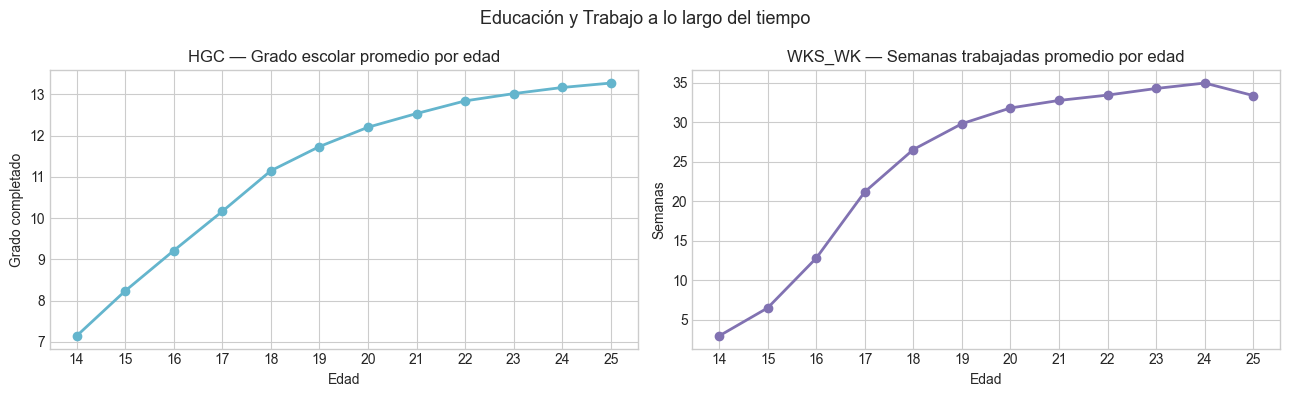

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Grado escolar promedio por edad
hgc_avg  = [df[c].clip(lower=0).mean() for c in hgc_cols]
hgc_ages = [int(c.replace('HGC_CY', '')) for c in hgc_cols]
axes[0].plot(hgc_ages, hgc_avg, marker='o', color='#64b5cd', linewidth=2)
axes[0].set_title('HGC — Grado escolar promedio por edad')
axes[0].set_xlabel('Edad'); axes[0].set_ylabel('Grado completado')
axes[0].set_xticks(hgc_ages)

# Semanas trabajadas promedio por edad
wks_avg  = [df[c].clip(lower=0).mean() for c in wks_cols]
wks_ages = [int(c.replace('WKS_WK_CY', '')) for c in wks_cols]
axes[1].plot(wks_ages, wks_avg, marker='o', color='#8172b2', linewidth=2)
axes[1].set_title('WKS_WK — Semanas trabajadas promedio por edad')
axes[1].set_xlabel('Edad'); axes[1].set_ylabel('Semanas')
axes[1].set_xticks(wks_ages)

plt.suptitle('Educación y Trabajo a lo largo del tiempo', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Diferencias por EVER_ASSAULT

Antes de construir el modelo, exploramos cómo difieren quienes reportaron asalto vs. quienes no. Esto nos da intuición sobre qué variables serán importantes.

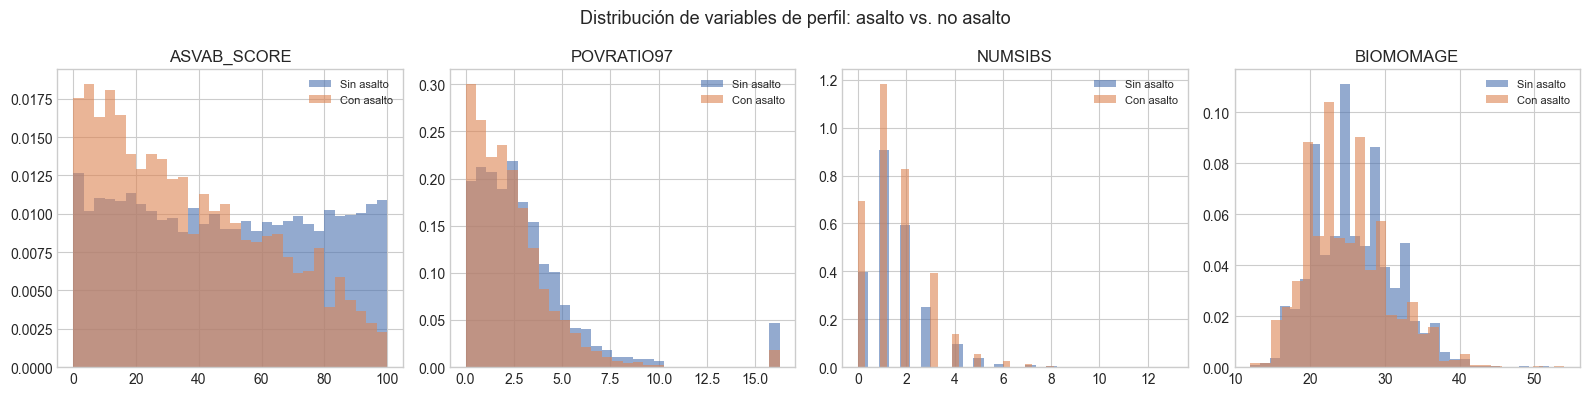

In [21]:
# Solo individuos con al menos una observación en assault
has_obs = df[assault_cols].notna().any(axis=1)
dfa = df[has_obs].copy()

# Comparación de variables estáticas por EVER_ASSAULT
comp_vars = ['ASVAB_SCORE', 'POVRATIO97', 'NUMSIBS', 'BIOMOMAGE']
comp_vars = [c for c in comp_vars if c in dfa.columns]

fig, axes = plt.subplots(1, len(comp_vars), figsize=(4 * len(comp_vars), 4))
for i, col in enumerate(comp_vars):
    g0 = dfa[dfa['EVER_ASSAULT'] == 0][col].dropna()
    g1 = dfa[dfa['EVER_ASSAULT'] == 1][col].dropna()
    axes[i].hist(g0, bins=30, alpha=0.6, label='Sin asalto', color='#4c72b0', density=True)
    axes[i].hist(g1, bins=30, alpha=0.6, label='Con asalto', color='#dd8452', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de variables de perfil: asalto vs. no asalto', fontsize=13)
plt.tight_layout()
plt.show()

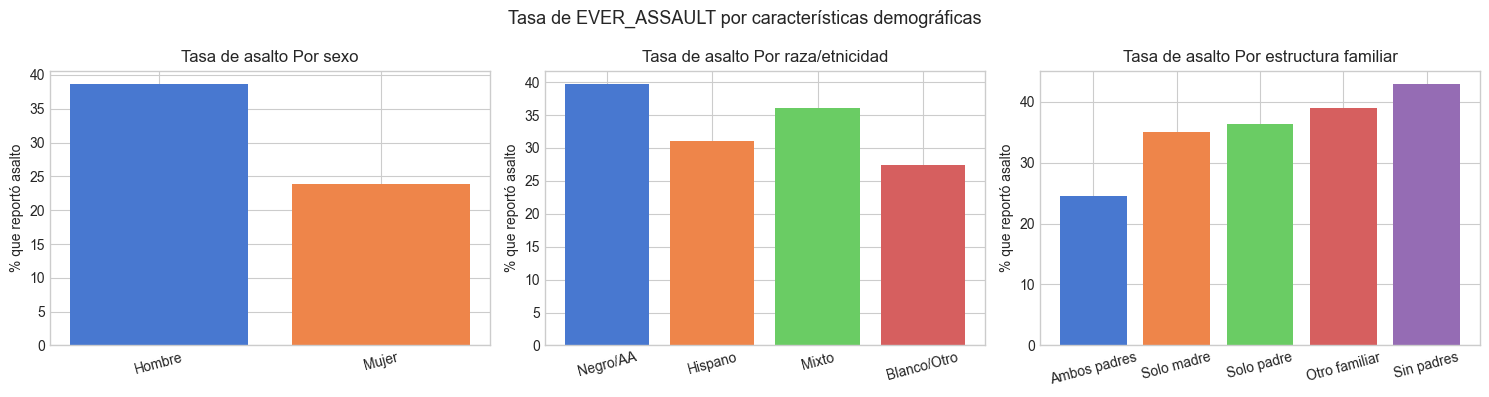

In [22]:
# Tasa de EVER_ASSAULT por raza, sexo y estructura familiar
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, label_map, title) in zip(axes, [
    ('SEX',           sex_labels,    'Por sexo'),
    ('RACE_ETHNICITY', race_labels,  'Por raza/etnicidad'),
    ('FMSTRC97',       fmstrc_labels,'Por estructura familiar'),
]):
    rate = dfa.groupby(col)['EVER_ASSAULT'].mean() * 100
    labels = [label_map.get(k, str(k)) for k in rate.index]
    ax.bar(labels, rate.values, color=sns.color_palette('muted', len(rate)))
    ax.set_title(f'Tasa de asalto {title}')
    ax.set_ylabel('% que reportó asalto')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Tasa de EVER_ASSAULT por características demográficas', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Preparación para Feature Importance

### Estrategia para evitar data leakage

El dataset es **longitudinal**: si usáramos `ASSAULT_CY20` para predecir `EVER_ASSAULT`, crearíamos un problema circular. Para evitarlo, construimos dos conjuntos de features:

1. **Features de perfil estático** (sexo, raza, familia, ingreso 1997, ASVAB): características fijas al inicio del estudio
2. **Features de comportamiento temprano** (edades 14-16): predictores históricos para fenómenos posteriores

Para un análisis de **asociación contemporánea** (no predictivo), usaremos todos los features agregados a nivel de vida completa.

In [23]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler

# ── Construir features agregados (toda la vida) ──────────────────────────────
agg = pd.DataFrame(index=dfa.index)
agg['PUBID'] = dfa['PUBID']

def safe_sum(df, cols):
    return df[cols].sum(axis=1, min_count=1)

# Features de crimen (excluimos assault para evitar leakage)
agg['TOTAL_DESTROY']    = safe_sum(dfa, destroy_cols)
agg['TOTAL_STEAL_LO']   = safe_sum(dfa, steal_lo_cols)
agg['TOTAL_STEAL_HI']   = safe_sum(dfa, steal_hi_cols)
agg['TOTAL_SELL_DRUGS'] = safe_sum(dfa, drugs_sell_cols)
agg['TOTAL_CARR_GUN']   = safe_sum(dfa, gun_cols)
agg['TOTAL_GANG']       = safe_sum(dfa, gang_cols)

# Features de justicia
agg['TOTAL_ARRESTS']    = dfa['TOTARRESTS']
agg['AGE_FIRST_ARREST'] = dfa['FIRSTARREST']
agg['TOTAL_INCARC']     = dfa['TOTINCARC']

# Sustancias
agg['TOTAL_ALCOHOL']    = safe_sum(dfa, alcohol_cols)
agg['TOTAL_MARIJUANA']  = safe_sum(dfa, marijuana_cols)
agg['TOTAL_HARD_DRUGS'] = safe_sum(dfa, hard_cols)
agg['TOTAL_SMOKING']    = safe_sum(dfa, smoking_cols)

# Trabajo e ingreso
agg['AVG_HHINC']        = dfa[hhinc_cols].clip(lower=0).mean(axis=1)
agg['AVG_RINC']         = dfa[rinc_cols].clip(lower=0).mean(axis=1)
agg['AVG_WKS_WORK']     = dfa[wks_cols].clip(lower=0).mean(axis=1)

# Educación
agg['MAX_GRADE']        = dfa[hgc_cols].clip(lower=0).max(axis=1)

# Variables estáticas de perfil
for col in STATIC_COLS:
    agg[col] = dfa[col]

# Target
agg['EVER_ASSAULT'] = dfa['EVER_ASSAULT']

print(f"Dataset para modelado: {agg.shape[0]:,} filas × {agg.shape[1]-2} features")
print(f"Target balance: {agg['EVER_ASSAULT'].mean():.1%} con asalto")

Dataset para modelado: 8,958 filas × 29 features
Target balance: 31.5% con asalto


In [24]:
# Separar X e y, imputar medianas
feature_cols = [c for c in agg.columns if c not in ['PUBID', 'EVER_ASSAULT']]

X_raw = agg[feature_cols]
y     = agg['EVER_ASSAULT'].astype(int)

# Eliminar filas donde el target es NaN
mask_valid = y.notna()
X_raw = X_raw[mask_valid]
y     = y[mask_valid]

# Imputación con mediana (robusto a outliers)
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X_raw), columns=feature_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Balance en train: {y_train.mean():.1%} positivos")

Train: (7166, 29) | Test: (1792, 29)
Balance en train: 31.5% positivos


## 13. Feature Importance — Random Forest

**Random Forest** calcula importancia por **reducción de impureza de Gini**: cuánto contribuye cada feature a reducir la incertidumbre al tomar decisiones de clasificación. Features con mayor reducción promedio a través de todos los árboles son más importantes.

Usamos `class_weight='balanced'` para compensar el desbalance de clases.

In [25]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=15,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Métricas en test
y_pred   = rf.predict(X_test)
y_prob   = rf.predict_proba(X_test)[:, 1]
auc      = roc_auc_score(y_test, y_prob)

print(f"AUC-ROC en test: {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Sin asalto', 'Con asalto']))

AUC-ROC en test: 0.8188

              precision    recall  f1-score   support

  Sin asalto       0.85      0.77      0.80      1228
  Con asalto       0.58      0.70      0.63       564

    accuracy                           0.75      1792
   macro avg       0.71      0.73      0.72      1792
weighted avg       0.76      0.75      0.75      1792



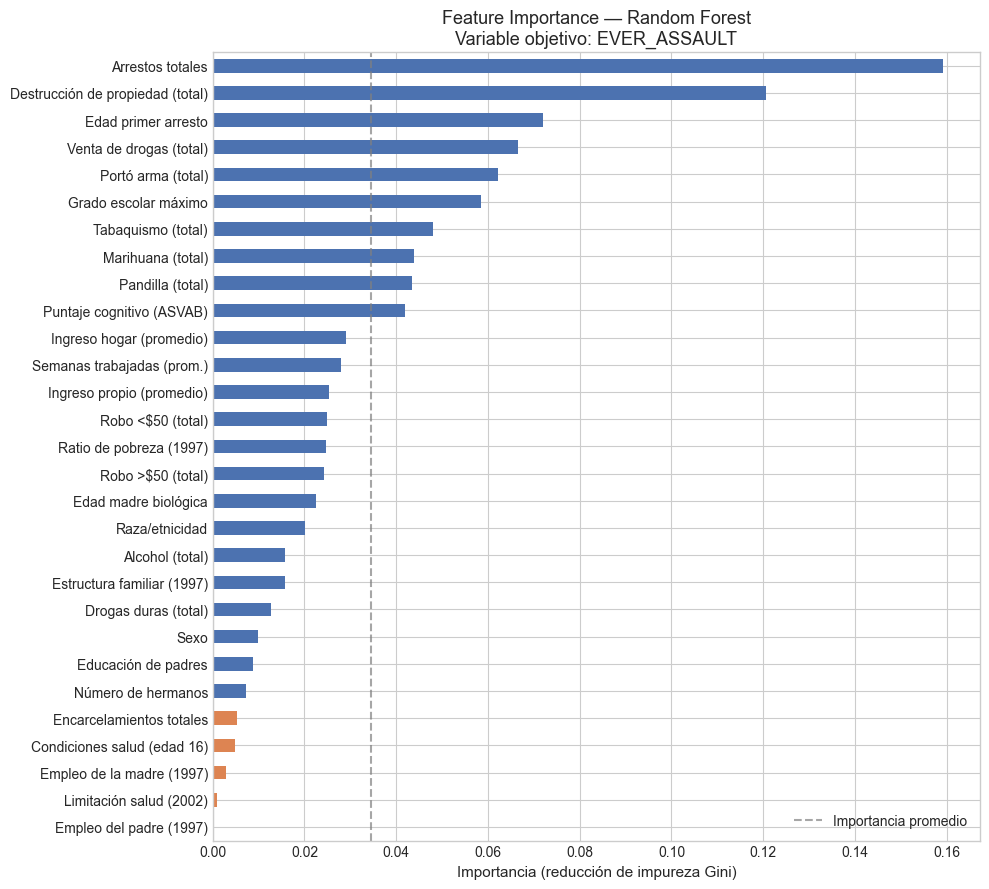


Top 10 features más importantes:
   1. Arrestos totales                        : 0.1593
   2. Destrucción de propiedad (total)        : 0.1206
   3. Edad primer arresto                     : 0.0720
   4. Venta de drogas (total)                 : 0.0664
   5. Portó arma (total)                      : 0.0622
   6. Grado escolar máximo                    : 0.0584
   7. Tabaquismo (total)                      : 0.0481
   8. Marihuana (total)                       : 0.0439
   9. Pandilla (total)                        : 0.0435
  10. Puntaje cognitivo (ASVAB)               : 0.0420


In [26]:
# Importancias de Gini
importances_gini = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

# Etiquetas descriptivas para las features
feature_labels = {
    'TOTAL_DESTROY':    'Destrucción de propiedad (total)',
    'TOTAL_STEAL_LO':   'Robo <$50 (total)',
    'TOTAL_STEAL_HI':   'Robo >$50 (total)',
    'TOTAL_SELL_DRUGS': 'Venta de drogas (total)',
    'TOTAL_CARR_GUN':   'Portó arma (total)',
    'TOTAL_GANG':       'Pandilla (total)',
    'TOTAL_ARRESTS':    'Arrestos totales',
    'AGE_FIRST_ARREST': 'Edad primer arresto',
    'TOTAL_INCARC':     'Encarcelamientos totales',
    'TOTAL_ALCOHOL':    'Alcohol (total)',
    'TOTAL_MARIJUANA':  'Marihuana (total)',
    'TOTAL_HARD_DRUGS': 'Drogas duras (total)',
    'TOTAL_SMOKING':    'Tabaquismo (total)',
    'AVG_HHINC':        'Ingreso hogar (promedio)',
    'AVG_RINC':         'Ingreso propio (promedio)',
    'AVG_WKS_WORK':     'Semanas trabajadas (prom.)',
    'MAX_GRADE':        'Grado escolar máximo',
    'SEX':              'Sexo',
    'RACE_ETHNICITY':   'Raza/etnicidad',
    'BIOMOMAGE':        'Edad madre biológica',
    'NUMSIBS':          'Número de hermanos',
    'MOMEMP97':         'Empleo de la madre (1997)',
    'DADEMP97':         'Empleo del padre (1997)',
    'FMSTRC97':         'Estructura familiar (1997)',
    'RESPARED':         'Educación de padres',
    'POVRATIO97':       'Ratio de pobreza (1997)',
    'ASVAB_SCORE':      'Puntaje cognitivo (ASVAB)',
    'HEALTHLIMIT2002':  'Limitación salud (2002)',
    'HEALTHCONDITIONS16': 'Condiciones salud (edad 16)',
}

imp_labeled = importances_gini.rename(index=lambda x: feature_labels.get(x, x))

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#dd8452' if i < 5 else '#4c72b0' for i in range(len(imp_labeled))]
imp_labeled.plot(kind='barh', ax=ax, color=colors[::-1])
ax.invert_yaxis()
ax.set_xlabel('Importancia (reducción de impureza Gini)', fontsize=11)
ax.set_title('Feature Importance — Random Forest\nVariable objetivo: EVER_ASSAULT', fontsize=13)
ax.axvline(imp_labeled.mean(), color='gray', linestyle='--', alpha=0.7, label='Importancia promedio')
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 features más importantes:")
for i, (feat, val) in enumerate(imp_labeled.head(10).items(), 1):
    print(f"  {i:2d}. {feat:40s}: {val:.4f}")

## 14. Feature Importance — Permutation Importance

La importancia por permutación es más robusta que Gini: mide cuánto **empeora el AUC** del modelo cuando se aleatoriza un feature. Evita el sesgo de Gini hacia variables con muchas categorías.

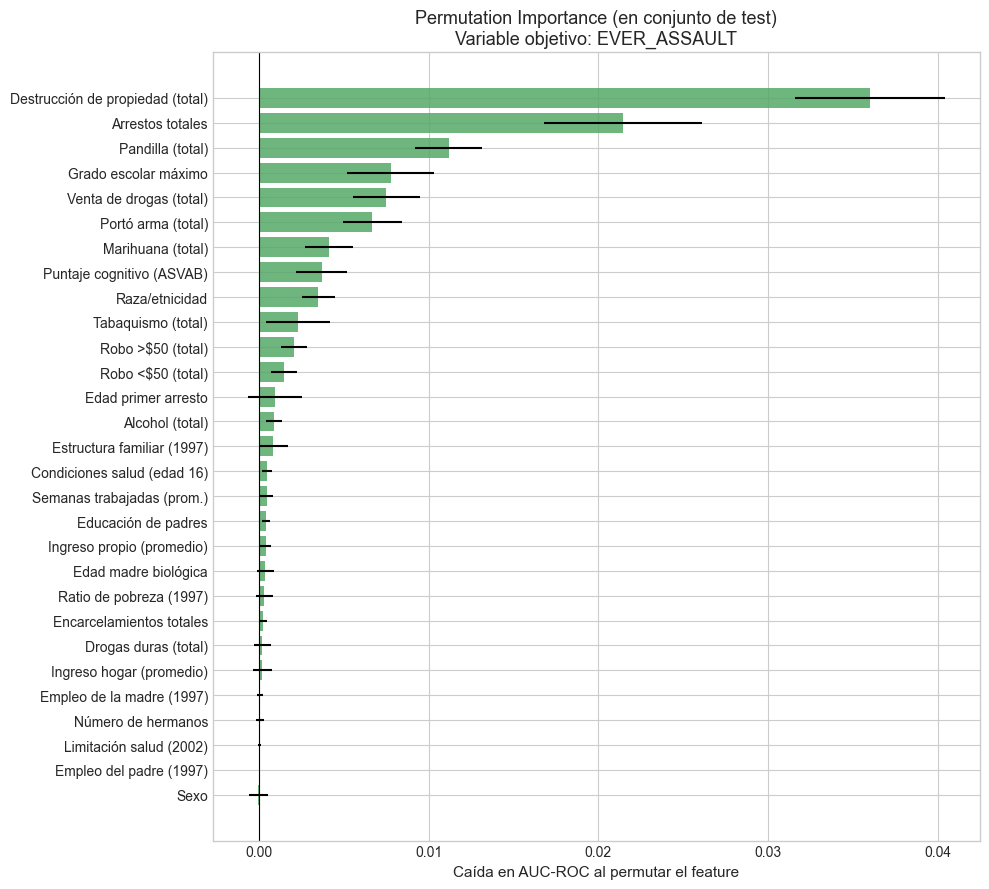


Features que más dañan el modelo al perderse:
  Destrucción de propiedad (total)        : 0.0360 ± 0.0044
  Arrestos totales                        : 0.0215 ± 0.0046
  Pandilla (total)                        : 0.0112 ± 0.0020
  Grado escolar máximo                    : 0.0078 ± 0.0026
  Venta de drogas (total)                 : 0.0075 ± 0.0020
  Portó arma (total)                      : 0.0067 ± 0.0017
  Marihuana (total)                       : 0.0041 ± 0.0014
  Puntaje cognitivo (ASVAB)               : 0.0037 ± 0.0015
  Raza/etnicidad                          : 0.0035 ± 0.0010
  Tabaquismo (total)                      : 0.0023 ± 0.0019


In [27]:
perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=20,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

perm_imp = pd.Series(perm.importances_mean, index=feature_cols)
perm_std = pd.Series(perm.importances_std,  index=feature_cols)
perm_imp_sorted = perm_imp.sort_values(ascending=False)
perm_std_sorted = perm_std[perm_imp_sorted.index]

perm_labeled = perm_imp_sorted.rename(index=lambda x: feature_labels.get(x, x))
perm_std_lab = perm_std_sorted.rename(index=lambda x: feature_labels.get(x, x))

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(perm_labeled.index[::-1], perm_labeled.values[::-1],
        xerr=perm_std_lab.values[::-1], color='#55a868', alpha=0.85)
ax.set_xlabel('Caída en AUC-ROC al permutar el feature', fontsize=11)
ax.set_title('Permutation Importance (en conjunto de test)\nVariable objetivo: EVER_ASSAULT', fontsize=13)
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nFeatures que más dañan el modelo al perderse:")
for feat, val, std in zip(perm_labeled.head(10).index,
                           perm_labeled.head(10).values,
                           perm_std_lab.head(10).values):
    print(f"  {feat:40s}: {val:.4f} ± {std:.4f}")

## 15. Resumen e interpretación

### Sobre el modelo
- El **AUC-ROC** indica qué tan bien el modelo separa a quienes reportaron asalto de quienes no. Un AUC de 0.85+ es considerado bueno para datos de encuesta con este nivel de ruido.
- Usamos **Gini + Permutation Importance** para comparar: si ambos coinciden en un feature, su importancia es robusta.

### Interpretación esperada de los features
| Feature | Relación con asalto | Mecanismo teórico |
|---------|--------------------|-----------------|
| Arrestos totales | Positiva fuerte | Proxy de historia criminal |
| Venta de drogas | Positiva | Contextos de violencia |
| Pandilla | Positiva | Exposición a violencia grupal |
| Portó arma | Positiva | Co-ocurrencia de comportamientos de riesgo |
| ASVAB (cognitivo) | Negativa | Mayor capital humano = menores costos de oportunidad del crimen |
| Ingreso del hogar | Negativa | Menor privación económica |
| Estructura familiar | Variable | Ausencia de un padre asociada a mayor riesgo |
| Sexo (hombre) | Positiva | Brecha de género en violencia es uno de los hallazgos más robustos en criminología |

### Limitaciones
1. **Auto-reporte**: ASSAULT no equivale exactamente a "aggravated assault" legal — captura asaltos self-reported, no arrestos por ese cargo específico
2. **Leakage potencial**: usar arrestos totales como feature puede ser demasiado correlacionado con el target
3. **Estructura longitudinal**: el panel permite análisis más sofisticados (efectos fijos, modelos de supervivencia) que van más allá de este EDA
4. **Pesos muestrales**: `SAMPWEIGHT_R1` debe usarse para inferencia representativa a nivel nacional

In [28]:
# Comparación lado a lado: Gini vs. Permutation
compare = pd.DataFrame({
    'Gini_rank':      range(1, len(imp_labeled) + 1),
    'Gini_imp':       imp_labeled.values,
    'Perm_imp':       [perm_labeled.get(f, np.nan) for f in imp_labeled.index],
}, index=imp_labeled.index)

compare['Perm_rank'] = compare['Perm_imp'].rank(ascending=False)
compare['Rank_diff'] = (compare['Gini_rank'] - compare['Perm_rank']).abs()

print("Comparación de rankings: Gini vs. Permutation Importance")
print("(Rank_diff alto = el método importa mucho para ese feature)")
print()
print(compare[['Gini_rank', 'Gini_imp', 'Perm_rank', 'Perm_imp', 'Rank_diff']]
      .sort_values('Gini_rank')
      .to_string(float_format='{:.4f}'.format))

Comparación de rankings: Gini vs. Permutation Importance
(Rank_diff alto = el método importa mucho para ese feature)

                                  Gini_rank  Gini_imp  Perm_rank  Perm_imp  Rank_diff
Arrestos totales                          1    0.1593     2.0000    0.0215     1.0000
Destrucción de propiedad (total)          2    0.1206     1.0000    0.0360     1.0000
Edad primer arresto                       3    0.0720    13.0000    0.0009    10.0000
Venta de drogas (total)                   4    0.0664     5.0000    0.0075     1.0000
Portó arma (total)                        5    0.0622     6.0000    0.0067     1.0000
Grado escolar máximo                      6    0.0584     4.0000    0.0078     2.0000
Tabaquismo (total)                        7    0.0481    10.0000    0.0023     3.0000
Marihuana (total)                         8    0.0439     7.0000    0.0041     1.0000
Pandilla (total)                          9    0.0435     3.0000    0.0112     6.0000
Puntaje cognitivo (ASV